<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB33 · PPO: aprender rápido sin romper nada

**Parte 4 · Aprendizaje por refuerzo de verdad — Lección 6**

> En el **NB32** construiste un actor-crítico con dos redes de PyTorch, y el palo de escoba aprendió desde cero. Pero también viste su lado oscuro: con una tasa de
> aprendizaje un poco alta, el actor llegaba a 500 puntos... y unas iteraciones después **se derrumbaba** y no volvía a levantarse.

Hoy vas a construir, **línea a línea**, el algoritmo que resolvió ese problema y que hoy es el más usado del mundo para entrenar robots: **PPO**, *Proximal Policy Optimization*
("optimización de la política con pasos **próximos**", es decir, **cercanos**). Lo publicó el equipo de OpenAI en 2017, y con él se han entrenado manos robóticas que resuelven el cubo de
Rubik, perros robot que corren por la montaña y los humanoides de los simuladores modernos.

Te adelanto un secreto: PPO es el actor-crítico del NB32 con **tres ideas** más. Las tres caben en una frase cada una, y las vamos a entender primero sin código.


## 1 · Los dos males del NB32

Mira lo que hacía el actor-crítico en cada iteración:

1. Jugaba 32 episodios. Cuando ya sabía sostener el palo, eso son 32 × 500 = **16.000 situaciones** vividas, con su acción, su recompensa y su ventaja.
2. Con todo eso, daba **un solo paso** de aprendizaje.
3. Y **tiraba** los 16.000 datos a la basura, para jugar otros 32 episodios.

**Primer mal: el desperdicio.** Jugar es lo **caro** (en un robot real, jugar es gastar tiempo, batería y motores; en simulación, tiempo de cálculo). Aprender de cada dato una sola vez
es como leer los apuntes del examen una vez y quemarlos.

**Segundo mal: la fragilidad.** Si para aprender más deprisa damos pasos más grandes (subiendo la tasa), un paso desafortunado puede estropear la política, y como el actor solo aprende de
lo que **él mismo** juega, una política estropeada genera datos malos que la estropean más (NB32, sección 14).

PPO arregla los dos a la vez. Vamos a ver cómo.


## 2 · Idea 1: aprovechar cada lote varias veces

La solución obvia al desperdicio: con el mismo lote de datos, dar **muchos** pasos de aprendizaje en vez de uno. Por ejemplo, recorrer los datos **10 veces**. A cada recorrido completo
de los datos se le llama **época** (como en el aprendizaje supervisado, NB18).

Y dentro de cada época, en vez de usar los 16.000 datos de golpe para un paso, se **barajan** y se trocean en **minilotes** de, por ejemplo, 1.024 datos, y se da un paso con cada
minilote. Así, de un solo lote salen 10 épocas × 16 minilotes = **160 pasos** de aprendizaje, en vez de 1.

```
lote jugado (16.000 situaciones)
   │
   ├── época 1:  barajar → [minilote][minilote][minilote]...  → un paso por minilote
   ├── época 2:  barajar → [minilote][minilote][minilote]...
   │   ...
   └── época 10: barajar → [minilote][minilote][minilote]...
```

¿Por qué barajar? Para que cada minilote sea una **mezcla** de situaciones de muchos episodios y momentos distintos, y no, por ejemplo, "los 1.024 primeros pasos del episodio 1", que se
parecen mucho entre sí. Es lo mismo que barajar las cartas antes de repartir.

### El problema que aparece

Pero hay una trampa, y es profunda. Los datos los jugó **la política de antes** del primer paso. Tras unos cuantos pasos, el actor ya es **otro**: quizá ya no elegiría esas acciones, o las
elegiría con probabilidades muy distintas. Seguir aprendiendo de esos datos como si fueran suyos es como si un entrenador te corrigiera viendo el vídeo de un partido que jugaste **con otro
estilo**: al principio sus consejos valen, pero cuanto más cambias tú, menos se aplican.

Y aún peor: si aprendemos demasiado de un mismo lote, el actor puede "**sobreaprender**" las casualidades de esos 32 episodios concretos (un golpe de viento afortunado, una acción que salió
bien de chiripa) y empujar su política muy lejos, hacia algo que en realidad no es mejor. Es la fragilidad del NB32, multiplicada por 160.

Hace falta, por tanto, **medir cuánto ha cambiado la política** y **ponerle un freno**. Las otras dos ideas hacen exactamente eso.


## 3 · Idea 2: la razón de probabilidades

¿Cómo se mide cuánto ha cambiado la política? Para cada situación del lote y la acción que se tomó, comparamos dos probabilidades:

- **p vieja**: la probabilidad que le daba a esa acción la política que **jugó** (la apuntamos al principio y no la tocamos más);
- **p nueva**: la probabilidad que le da **ahora** el actor, tras algunos pasos de aprendizaje.

Y las dividimos. A eso se le llama la **razón** (en inglés, *ratio*), y se escribe **r**:

```
         p nueva (de esa acción en esa situación)
   r  =  ─────────────────────────────────────────
         p vieja (de esa acción en esa situación)
```

| r | Qué significa |
|---|---|
| 1 | La política no ha cambiado nada para esa acción. |
| 1,5 | La acción es ahora un 50 % **más** probable que cuando se jugó. |
| 0,8 | La acción es ahora un 20 % **menos** probable. |
| 1.000 | La política ha cambiado **muchísimo**: ¡mil veces más probable! |

Al principio de cada lote, todas las r valen exactamente 1 (aún no ha cambiado nada). Con cada paso de aprendizaje, se van separando de 1.

Un detalle práctico. Nosotros trabajamos con **log-probabilidades** (NB28: son más cómodas y no se hacen diminutas). ¿Cómo se divide con logaritmos? En el NB28 vimos que el logaritmo
convierte las multiplicaciones en sumas; igual, convierte las **divisiones en restas**. Así que:

```
r  =  e^( log p nueva  −  log p vieja )
```

Restar los logaritmos y aplicar la exponencial: eso es dividir las probabilidades.

### El nuevo objetivo

En el NB32, el actor subía la media de **log p × ventaja**. PPO usa, en su lugar, **r × ventaja**: "sube la probabilidad (comparada con la de antes) de las acciones con ventaja positiva, y
baja la de las negativas". Al principio de cada lote, cuando r = 1, las dos dan **exactamente la misma pendiente** (es una pequeña propiedad de los logaritmos: la pendiente de log p es la
pendiente de p dividida por p, y eso es justo la pendiente de r = p/p vieja cuando p = p vieja). O sea: el primer paso es el del NB32. La diferencia es que con r **podemos ver** cuánto nos
hemos alejado... y frenar.


## 4 · Idea 3: el recorte (el cinturón de seguridad)

Aquí está el corazón de PPO. Elegimos un margen, que se llama **ε** (la letra griega **épsilon**), normalmente **0,2**. Y decimos:

> Una vez que una acción buena ya es un 20 % más probable que antes, **ya no hay premio** por hacerla todavía más probable con este lote. Y una vez que una acción mala ya es un 20 % menos
> probable, **ya no hay premio** por hundirla más.

Para conseguirlo, se **recorta** r al intervalo [1 − ε, 1 + ε] = [0,8; 1,2] (como el `clip` de NumPy, NB15), y el objetivo de cada dato es el **mínimo** de dos cosas:

```
objetivo = mínimo de (  r × ventaja ,   recortar(r, 0,8, 1,2) × ventaja  )
```

Parece un trabalenguas, así que vamos caso por caso:

| Ventaja | r | Qué pasa | ¿Sigue aprendiendo de este dato? |
|---|---|---|---|
| **positiva** (acción buena) | 1,1 | Aún dentro del margen: objetivo = r × ventaja. | **Sí**: sube la probabilidad. |
| **positiva** | 1,5 | Ya subió más de un 20 %: el mínimo es el recortado, 1,2 × ventaja, **fijo**. | **No**: ya no hay pendiente. ¡Freno! |
| **negativa** (acción mala) | 0,9 | Dentro del margen. | **Sí**: baja la probabilidad. |
| **negativa** | 0,5 | Ya bajó más de un 20 %: el objetivo queda fijo en 0,8 × ventaja. | **No**. ¡Freno! |

La clave es que, cuando un dato "se recorta", su objetivo se vuelve **plano** (constante): no tiene pendiente, así que **deja de empujar** a la red. Cada dato puede empujar a la política
solo hasta cierto punto; después, se calla.

¿Y para qué el "mínimo"? Para que el recorte solo actúe cuando **frena**, nunca cuando sería un premio extra. Por ejemplo, con ventaja positiva y r = 0,5 (¡el actor ha hecho **menos** probable
una acción buena, por error!), el mínimo es r × ventaja, sin recortar, así que **sí** hay pendiente para corregir ese error. El recorte frena los excesos, pero nunca impide arreglar un fallo.

Veámoslo dibujado. Primero, las piezas de siempre:


In [1]:
import torch
from torch import nn
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt


Y ahora, el objetivo de PPO para un solo dato, en función de r, con ventaja +1 y con ventaja −1. `torch.clamp` es el recorte (el `clip` de NumPy, NB31) y `torch.minimum`, el mínimo dato a dato:

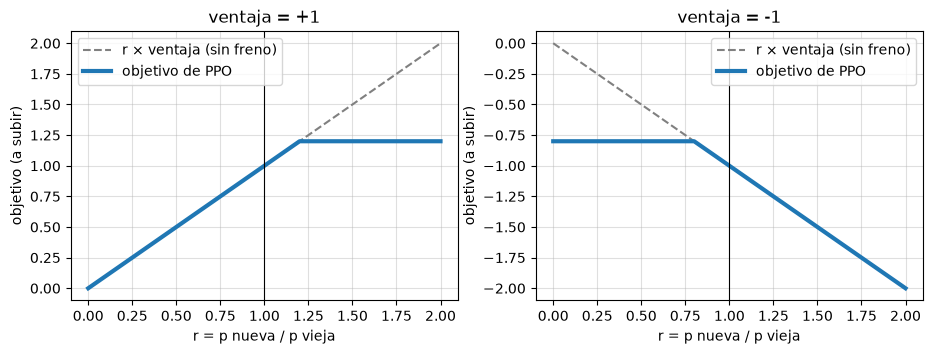

In [2]:
r = torch.linspace(0, 2, 201)
epsilon = 0.2

plt.figure(figsize=(11, 3.5))
for k, ventaja in enumerate([1.0, -1.0]):
    sin_recorte = r * ventaja
    con_recorte = torch.minimum(r * ventaja, torch.clamp(r, 1 - epsilon, 1 + epsilon) * ventaja)
    plt.subplot(1, 2, k + 1)
    plt.plot(r, sin_recorte, "--", color="gray", label="r × ventaja (sin freno)")
    plt.plot(r, con_recorte, linewidth=3, label="objetivo de PPO")
    plt.axvline(1, color="black", linewidth=0.8)
    plt.title(f"ventaja = {ventaja:+.0f}")
    plt.xlabel("r = p nueva / p vieja")
    plt.ylabel("objetivo (a subir)")
    plt.legend()
    plt.grid(True, alpha=0.4)
plt.show()


Léelo como un excursionista que **sube** por la línea gruesa (el objetivo se sube):

- **Izquierda, ventaja positiva.** Subir el objetivo es ir hacia la derecha (r mayor). Pero en r = 1,2 la línea se vuelve **horizontal**: ya no hay cuesta, y el excursionista se para. Sin
  recorte (gris), la cuesta seguiría para siempre, invitando a hacer la acción infinitamente más probable.
- **Derecha, ventaja negativa.** Subir es ir hacia la **izquierda** (r menor). En r = 0,8 la línea se aplana: freno. Y fíjate en la derecha de esa gráfica: si por error r creciera (la acción
  mala se hiciera **más** probable), la línea sigue en cuesta, y el excursionista **vuelve**. El freno solo actúa en la dirección del exceso.

Esto es todo PPO: una **región de confianza** alrededor de la política que jugó. Dentro de ella, aprendes con libertad; fuera, el objetivo deja de animarte. Ningún lote puede arrastrar a la
política lejos de donde estaba, por muchas épocas que hagas. De ahí el nombre: pasos **próximos**.


## 5 · Un regalo de propina: el mando λ (GAE)

En el NB32 tuvimos que elegir entre dos formas de calcular la ventaja:

- **Montecarlo**: G − V, todo lo que pasó hasta el final. Honesta pero con **mucho ruido**.
- **Diferencia temporal**: δ = r + γ·V(siguiente) − V(ahora), un solo paso y fiarse del crítico. Con **poco ruido** pero con el **sesgo** del crítico.

Y te prometí un **mando** para elegir cualquier punto intermedio. Se llama **GAE**, *Generalized Advantage Estimation* ("estimación generalizada de la ventaja"), y es la que usa PPO.
La idea: sumar las sorpresas δ de **varios** pasos seguidos, cada vez con menos peso:

```
ventaja(t) = δ(t)  +  (γλ) × δ(t+1)  +  (γλ)² × δ(t+2)  +  ...
```

La letra λ (**lambda**, la "l" griega) es el mando, entre 0 y 1:

- Con **λ = 0**, todos los términos menos el primero se anulan: ventaja = δ(t). **Diferencia temporal pura.**
- Con **λ = 1**, se suman todas las sorpresas hasta el final... y ocurre algo precioso: los V intermedios **se cancelan** entre sí (cada V(siguiente) de un paso se resta como V(ahora) en el
  paso siguiente), y queda exactamente G − V. **Montecarlo puro.**
- Con valores intermedios, como el habitual **λ = 0,95**, se mira bastante hacia delante pero cada vez fiándose más del crítico.

Igual que el retorno (NB29), se calcula muy fácil **de atrás hacia delante**, porque cada ventaja es "mi sorpresa + γλ × la ventaja del paso siguiente":

```
ventaja(t) = δ(t) + γ·λ × ventaja(t+1)
```

(Y si el palo cae en el paso t, no hay paso siguiente: la cadena se corta ahí.)


## 6 · Las piezas, y la comprobación del mando

Traemos del NB32, sin cambiar nada, el actor, el crítico, la función de jugar y las entradas del crítico (con el reloj). Si vienes del NB32, ya las conoces línea a línea:


In [3]:
ESCALA = torch.tensor([10.0, 20.0])

class Actor(nn.Module):
    def __init__(self, ocultas=32, sigma_inicial=0.25):
        super().__init__()
        self.red = nn.Sequential(nn.Linear(2, ocultas), nn.Tanh(), nn.Linear(ocultas, 1))
        self.log_sigma = nn.Parameter(torch.tensor(np.log(sigma_inicial), dtype=torch.float32))

    def media(self, observaciones):
        return self.red(observaciones / ESCALA).squeeze(-1)

    def campana(self, observaciones):
        return Normal(self.media(observaciones), self.log_sigma.exp())

class Critico(nn.Module):
    def __init__(self, ocultas=64):
        super().__init__()
        self.red = nn.Sequential(nn.Linear(3, ocultas), nn.Tanh(), nn.Linear(ocultas, 1))
        self.escala = torch.tensor([10.0, 20.0, 500.0])

    def forward(self, entradas):
        return self.red(entradas / self.escala).squeeze(-1) * 100

def jugar(actor, n_episodios, generador, pasos_maximos=500):
    inclinacion = np.full(n_episodios, 2.0)
    velocidad = np.zeros(n_episodios)
    vivos = np.ones(n_episodios, dtype=bool)
    observaciones = np.zeros((pasos_maximos, n_episodios, 2), dtype=np.float32)
    acciones = np.zeros((pasos_maximos, n_episodios), dtype=np.float32)
    recompensas = np.zeros((pasos_maximos, n_episodios), dtype=np.float32)
    estaba_vivo = np.zeros((pasos_maximos, n_episodios), dtype=bool)
    sigma = actor.log_sigma.exp().item()
    for t in range(pasos_maximos):
        observacion = np.stack([inclinacion, velocidad], axis=1).astype(np.float32)
        with torch.no_grad():
            media = actor.media(torch.from_numpy(observacion)).numpy()
        accion = media + sigma * generador.standard_normal(n_episodios)
        observaciones[t], acciones[t], estaba_vivo[t] = observacion, accion, vivos
        empuje = np.clip(accion, -1, 1) * 40
        aceleracion = 10 * inclinacion + empuje + generador.uniform(-30, 30, n_episodios)
        velocidad = velocidad + aceleracion * 0.02
        inclinacion = inclinacion + velocidad * 0.02
        vivos = vivos & (np.abs(inclinacion) <= 30)
        recompensas[t] = np.where(vivos, 1 - (inclinacion / 30) ** 2, 0.0)
        if not vivos.any():
            break
    return observaciones, acciones, recompensas * estaba_vivo, estaba_vivo

def entradas_del_critico(observaciones):
    pasos, n_episodios, _ = observaciones.shape
    reloj = np.broadcast_to(np.arange(pasos, dtype=np.float32)[:, None, None], (pasos, n_episodios, 1))
    return np.concatenate([observaciones, reloj], axis=2)

def retornos_desde_cada_paso(recompensas, gamma=0.99):
    G = np.zeros_like(recompensas)
    acumulado = np.zeros(recompensas.shape[1], dtype=np.float32)
    for t in reversed(range(recompensas.shape[0])):
        acumulado = recompensas[t] + gamma * acumulado
        G[t] = acumulado
    return G

print("Piezas del NB32 listas")


Piezas del NB32 listas


(Un solo cambio, de comodidad: `jugar` ya devuelve las recompensas multiplicadas por `estaba_vivo`, para no tener que hacerlo fuera cada vez.)

Ahora la pieza nueva, **GAE**, tal cual la fórmula de la sección 5: primero todas las sorpresas δ (como en el NB32), y luego la suma hacia atrás con el factor γλ, cortando la cadena donde
el palo cae:


In [4]:
def ventajas_gae(valores, recompensas, estaba_vivo, gamma=0.99, lam=0.95):
    valor_siguiente = np.zeros_like(valores)
    valor_siguiente[:-1] = valores[1:]
    sigue_vivo = np.zeros_like(estaba_vivo)
    sigue_vivo[:-1] = estaba_vivo[1:]
    delta = recompensas + gamma * valor_siguiente * sigue_vivo - valores      # las sorpresas (NB32)

    ventajas = np.zeros_like(valores)
    acumulado = np.zeros(valores.shape[1], dtype=np.float32)
    for t in reversed(range(valores.shape[0])):
        acumulado = delta[t] + gamma * lam * sigue_vivo[t] * acumulado
        ventajas[t] = acumulado
    return ventajas


¿Hace de verdad lo que prometimos? Comprobémoslo con un experimento: jugamos unos episodios con un actor sin entrenar, nos inventamos las opiniones de un "crítico" cualquiera (números al azar:
la cancelación debe funcionar **sea cual sea** el crítico) y comprobamos los dos extremos del mando:


In [5]:
torch.manual_seed(0)
generador = np.random.default_rng(0)
obs, acc, rec, vivo = jugar(Actor(), 8, generador)
valores_inventados = generador.uniform(0, 50, rec.shape).astype(np.float32)

G = retornos_desde_cada_paso(rec)
delta = ventajas_gae(valores_inventados, rec, vivo, lam=0.0)
montecarlo = ventajas_gae(valores_inventados, rec, vivo, lam=1.0)

print("¿λ = 1 da G − V (Montecarlo)?  ", np.allclose(montecarlo[vivo], (G - valores_inventados)[vivo], atol=1e-3))
print("¿λ = 0 da la sorpresa de un paso?", np.allclose(delta[1:][vivo[1:]],
      (rec[1:] + 0.99 * np.append(valores_inventados[2:], np.zeros((1, 8)), axis=0) * np.append(vivo[2:], np.zeros((1, 8), bool), axis=0)
       - valores_inventados[1:])[vivo[1:]], atol=1e-3))


¿λ = 1 da G − V (Montecarlo)?   True
¿λ = 0 da la sorpresa de un paso? True


**Los dos extremos, comprobados.** Con λ = 1 los V intermedios se cancelan y sale Montecarlo, con un crítico de números al azar; con λ = 0, solo queda la sorpresa de un paso. (La segunda
comprobación es un poco enrevesada de escribir porque calcula δ "a mano" desplazando las tablas; lo importante es el `True`.)

## 7 · El algoritmo completo

Ya tienes todas las piezas. PPO, en cada iteración:

1. **Jugar** un lote de episodios con el actor actual.
2. El **crítico opina** de cada situación vivida; calcular las **ventajas con GAE** (λ = 0,95) y **normalizarlas** (NB30).
3. **Apuntar** la log-probabilidad de cada acción según la política que jugó (**log p vieja**), y no tocarla más.
4. Repetir durante **10 épocas**: barajar los datos y, para cada **minilote**:
   - r = e^(log p nueva − log p vieja);
   - pérdida del actor = −media( mínimo( r × ventaja, recortar(r, 0,8, 1,2) × ventaja ) ) (el signo menos, como en el NB32, para que PyTorch **baje** lo que queremos subir);
   - pérdida del crítico = error cuadrático entre su opinión y su objetivo;
   - un paso de Adam para cada uno.

¿El objetivo del crítico? Ventaja + V(ahora): "lo que esperaba, corregido por la sorpresa". Con GAE es una mezcla de G y de sus propias opiniones, coherente con el mando λ.

Una pieza nueva de PyTorch: **`torch.randperm(n)`** da los números del 0 al n − 1 **barajados** (una *permutación* al azar). Recorrerlos de 1.024 en 1.024 es exactamente "barajar y trocear en
minilotes".

Y apuntaremos, en cada iteración, **cuánto ha cambiado la política** al terminar las épocas: la media de |r − 1| sobre todo el lote (0 = nada; 0,1 = un 10 % de media) y el r **más grande**.
Así veremos el freno trabajar.


In [6]:
def entrenar_ppo(semilla=0, iteraciones=80, n_episodios=32, tasa=0.01, epocas=10, minilote=1024,
                 recorte=0.2, lam=0.95, gamma=0.99, avisar_cada=None):
    torch.manual_seed(semilla)
    generador = np.random.default_rng(semilla)
    actor, critico = Actor(), Critico()
    optim_actor = torch.optim.Adam(actor.parameters(), lr=tasa)
    optim_critico = torch.optim.Adam(critico.parameters(), lr=0.01)
    historial, sigmas, cambios, r_maximos = [], [], [], []

    for iteracion in range(iteraciones):
        # 1. jugar
        obs, acc, rec, vivo = jugar(actor, n_episodios, generador)
        historial.append(rec.sum(axis=0).mean())
        sigmas.append(actor.log_sigma.exp().item())

        # 2. el crítico opina; ventajas con GAE
        entradas = torch.from_numpy(entradas_del_critico(obs))
        with torch.no_grad():
            valores = critico(entradas).numpy()
        ventajas = ventajas_gae(valores, rec, vivo, gamma, lam)
        objetivo_critico = torch.from_numpy((ventajas + valores)[vivo])
        ventajas = ventajas[vivo]
        ventajas = torch.from_numpy((ventajas - ventajas.mean()) / (ventajas.std() + 1e-8))

        # 3. apuntar la política que jugó
        O, A, E = torch.from_numpy(obs[vivo]), torch.from_numpy(acc[vivo]), entradas[vivo]
        with torch.no_grad():
            log_p_vieja = actor.campana(O).log_prob(A)

        # 4. épocas y minilotes
        n = len(ventajas)
        for epoca in range(epocas):
            orden = torch.randperm(n)
            for inicio in range(0, n, minilote):
                i = orden[inicio:inicio + minilote]
                r = (actor.campana(O[i]).log_prob(A[i]) - log_p_vieja[i]).exp()
                if recorte is None:                                     # (para el experimento sin freno)
                    perdida_actor = -(r * ventajas[i]).mean()
                else:
                    perdida_actor = -torch.minimum(r * ventajas[i],
                                                   torch.clamp(r, 1 - recorte, 1 + recorte) * ventajas[i]).mean()
                optim_actor.zero_grad()
                perdida_actor.backward()
                optim_actor.step()

                perdida_critico = ((critico(E[i]) - objetivo_critico[i]) ** 2).mean()
                optim_critico.zero_grad()
                perdida_critico.backward()
                optim_critico.step()

        # ¿cuánto ha cambiado la política en esta iteración?
        with torch.no_grad():
            r_final = (actor.campana(O).log_prob(A) - log_p_vieja).exp()
        cambios.append((r_final - 1).abs().mean().item())
        r_maximos.append(r_final.max().item())

        if avisar_cada and iteracion % avisar_cada == 0:
            print(f"iteración {iteracion:3d} | retorno {historial[-1]:6.1f} | σ {sigmas[-1]:.3f} | "
                  f"cambio medio {cambios[-1]:.3f} | r máximo {r_maximos[-1]:7.1f}")
    return actor, critico, {"retorno": historial, "sigma": sigmas, "cambio": cambios, "r_max": r_maximos}


Fíjate en lo poco que se diferencia del `entrenar` del NB32: el bloque 3 (apuntar la política vieja), el bucle de épocas y minilotes, y la pérdida del actor con `r` y el recorte. Ese es
todo el "secreto" del algoritmo más usado del mundo.

(La función devuelve las curvas en un **diccionario**, NB21, para no tener que devolver cinco cosas sueltas.)

## 8 · ¡A entrenar!

Semilla 0, 80 iteraciones de 32 episodios, con una tasa de 0,01: **el doble** de la que usamos en el NB32 (allí tuvimos que bajar a 0,005 porque con tasas mayores el actor se derrumbaba). Tarda
uno o dos minutos en la Pi (cada iteración da cientos de pasos de aprendizaje, no uno):


In [7]:
import time

inicio = time.time()
actor, critico, curvas_ppo = entrenar_ppo(semilla=0, avisar_cada=10)
print(f"Tiempo: {time.time() - inicio:.0f} s")
print("Supera 490 por primera vez en la iteración", next(i for i, x in enumerate(curvas_ppo["retorno"]) if x > 490))


iteración   0 | retorno   42.6 | σ 0.250 | cambio medio 0.098 | r máximo     1.6


iteración  10 | retorno   46.3 | σ 0.234 | cambio medio 0.079 | r máximo     1.5


iteración  20 | retorno   60.8 | σ 0.264 | cambio medio 0.123 | r máximo     1.8


iteración  30 | retorno   99.8 | σ 0.240 | cambio medio 0.099 | r máximo     1.6


iteración  40 | retorno  129.8 | σ 0.261 | cambio medio 0.064 | r máximo     1.5


iteración  50 | retorno  371.2 | σ 0.240 | cambio medio 0.052 | r máximo     1.4


iteración  60 | retorno  499.4 | σ 0.209 | cambio medio 0.074 | r máximo     1.5


iteración  70 | retorno  499.5 | σ 0.188 | cambio medio 0.019 | r máximo     1.1


Tiempo: 48 s
Supera 490 por primera vez en la iteración 54


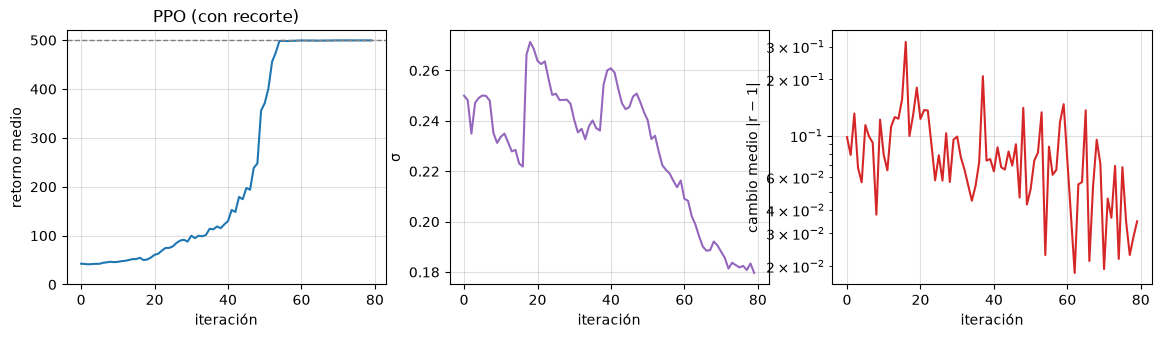

In [8]:
def dibujar(curvas, titulo):
    plt.figure(figsize=(14, 3.3))
    plt.subplot(1, 3, 1)
    plt.plot(curvas["retorno"])
    plt.axhline(500, color="gray", linestyle="--", linewidth=1)
    plt.ylim(0, 520)
    plt.title(titulo)
    plt.xlabel("iteración")
    plt.ylabel("retorno medio")
    plt.grid(True, alpha=0.4)
    plt.subplot(1, 3, 2)
    plt.plot(curvas["sigma"], color="tab:purple")
    plt.xlabel("iteración")
    plt.ylabel("σ")
    plt.grid(True, alpha=0.4)
    plt.subplot(1, 3, 3)
    plt.plot(curvas["cambio"], color="tab:red")
    plt.yscale("log")
    plt.xlabel("iteración")
    plt.ylabel("cambio medio |r − 1|")
    plt.grid(True, alpha=0.4)
    plt.show()

dibujar(curvas_ppo, "PPO (con recorte)")


**Aprende, y no se rompe.** El palo pasa de ~45 puntos a ~500 (lo supera hacia la iteración 55), y una vez arriba **se queda** arriba, sin un solo bajón. En el NB32, el actor-crítico con
diferencia temporal necesitó entre 78 y 94 iteraciones para superar los 490; PPO lo hace antes, con una tasa doble, y sin derrumbes.

Mira la gráfica de la derecha (en escala logarítmica, NB28): el **cambio medio** de la política en cada iteración se queda **entre un 2 % y un 30 %**, casi siempre por debajo del 10 %, por muchas
épocas y minilotes que haga, y el r máximo no pasa de 2. Ese es el cinturón de seguridad en acción: cada lote puede mover la política, pero solo un poquito. (No es exactamente 0,2, el margen ε:
muchas acciones no llegan al tope, y el recorte es por dato, no un límite absoluto; pero mantiene los cambios a raya.) Y al final, cuando ya sabe, los cambios se hacen aún más pequeños.

La σ, en el centro, sube y baja durante el aprendizaje y al final baja de 0,25 a 0,18: menos exploración cuando ya domina la tarea, como en el NB32.

## 9 · El experimento clave: ¿y sin el freno?

Ahora la prueba que demuestra que el recorte importa. Repetimos **exactamente lo mismo** (10 épocas, minilotes, GAE, tasa 0,01), pero **sin recortar** r: la pérdida del actor es solo
−media(r × ventaja). Lo probamos con tres semillas (tarda alrededor de dos minutos):


In [9]:
sin_freno = []
for semilla in range(3):
    _, _, curvas = entrenar_ppo(semilla=semilla, recorte=None)
    sin_freno.append(curvas)
    llega = next((i for i, x in enumerate(curvas["retorno"]) if x > 490), None)
    print(f"semilla {semilla}: supera 490 en la iteración {llega} | termina en {np.mean(curvas['retorno'][-5:]):5.1f} | "
          f"r máximo visto {max(curvas['r_max']):9.1f} | σ final {curvas['sigma'][-1]:.4f}")


semilla 0: supera 490 en la iteración 19 | termina en  48.4 | r máximo visto    1053.1 | σ final 0.0287


semilla 1: supera 490 en la iteración 47 | termina en  33.7 | r máximo visto    1347.7 | σ final 0.0548


semilla 2: supera 490 en la iteración None | termina en  48.4 | r máximo visto    2160.2 | σ final 0.0259


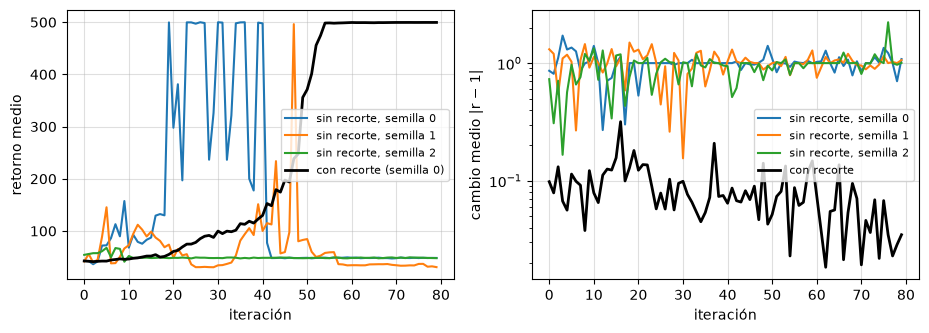

In [10]:
plt.figure(figsize=(11, 3.5))
plt.subplot(1, 2, 1)
for semilla, curvas in enumerate(sin_freno):
    plt.plot(curvas["retorno"], label=f"sin recorte, semilla {semilla}")
plt.plot(curvas_ppo["retorno"], color="black", linewidth=2, label="con recorte (semilla 0)")
plt.xlabel("iteración")
plt.ylabel("retorno medio")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.4)
plt.subplot(1, 2, 2)
for semilla, curvas in enumerate(sin_freno):
    plt.plot(curvas["cambio"], label=f"sin recorte, semilla {semilla}")
plt.plot(curvas_ppo["cambio"], color="black", linewidth=2, label="con recorte")
plt.yscale("log")
plt.xlabel("iteración")
plt.ylabel("cambio medio |r − 1|")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.4)
plt.show()


Esto es lo que hay que mirar:

1. **Sin freno, a veces aprende rapidísimo**: la semilla 0 supera los 490 en la iteración 19, mucho antes que con recorte (hacia la 55). Reutilizar cada lote 10 veces es muy potente.
2. **Pero es un caos**: fíjate en la curva azul, que salta de 500 a 200 y vuelve a 500 de una iteración a la siguiente. La semilla 1 llega a 490 en un solo pico (iteración 47), y la 2 **ni siquiera
   aprende**.
3. **Y al final se derrumban todas**, a entre 34 y 48 puntos: el nivel del **azar** (~45) o por debajo. Y no se recuperan.
4. A la derecha, el porqué: el cambio medio de la política por iteración ronda **1** (es decir, las probabilidades cambian por completo de un lote al siguiente: diez veces más que con recorte), y
   el r máximo llega a **más de mil**: acciones que se han vuelto mil veces más probables con un solo lote.

¿Y por qué no se recupera? Mira la σ final: ha caído de 0,25 a entre **0,03 y 0,05**. La política se ha vuelto **casi determinista**: el actor empuja siempre de la misma forma, que tumba el palo
enseguida. Y con σ casi cero ya **no explora**: no prueba nada distinto, así que no puede descubrir que se equivoca. Está atrapado.

Es la **espiral** del NB32 a lo grande: sin cinturón, cada lote empuja la política tan lejos como quiere, y una sola sobreinterpretación basta para despeñarla. **El recorte es lo que convierte "aprender
muchas veces de cada lote" de una idea suicida en el algoritmo más usado del mundo.**


## 10 · El examen en el entorno oficial

Como en el NB32, examinamos al actor de PPO en el entorno oficial `PaloDeEscoba-v0` (la misma clase del NB25), con la acción media (determinista) y semillas de viento que no ha visto. Y como
vimos que el viento de ±30 se le queda corto, le subimos también el viento:


In [11]:
import gymnasium as gym
from gymnasium import spaces

class PaloDeEscobaEnv(gym.Env):
    def __init__(self, viento_maximo=30.0):
        super().__init__()
        self.viento_maximo = viento_maximo
        self.empuje_maximo = 40.0
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(2,), dtype=np.float32)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.inclinacion = 0.0
        self.velocidad = 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.inclinacion = 2.0
        self.velocidad = 0.0
        return self._observacion(), {}

    def step(self, action):
        empuje = float(np.clip(action[0], -1.0, 1.0)) * self.empuje_maximo
        viento = self.np_random.uniform(-self.viento_maximo, self.viento_maximo)
        aceleracion = 10 * self.inclinacion + empuje + viento
        self.velocidad = self.velocidad + aceleracion * 0.02
        self.inclinacion = self.inclinacion + self.velocidad * 0.02
        terminado = bool(abs(self.inclinacion) > 30)
        recompensa = 0.0 if terminado else float(1 - (self.inclinacion / 30) ** 2)
        return self._observacion(), recompensa, terminado, False, {"viento": viento}

    def _observacion(self):
        return np.array([self.inclinacion, self.velocidad], dtype=np.float32)

gym.register(id="PaloDeEscoba-v0", entry_point=PaloDeEscobaEnv, max_episode_steps=500)

def examen(actor, n_episodios=20, viento_maximo=30.0):
    entorno = gym.make("PaloDeEscoba-v0", viento_maximo=viento_maximo)
    retornos = []
    for episodio in range(n_episodios):
        observacion, info = entorno.reset(seed=1000 + episodio)
        retorno, terminado, truncado = 0.0, False, False
        while not (terminado or truncado):
            with torch.no_grad():
                accion = actor.media(torch.from_numpy(observacion)).item()
            observacion, recompensa, terminado, truncado, info = entorno.step(np.array([accion]))
            retorno += recompensa
        retornos.append(retorno)
    return np.array(retornos)

for viento in [30, 60, 80, 100]:
    r = examen(actor, viento_maximo=viento)
    print(f"viento ±{viento:3d}: retorno medio {r.mean():6.1f} | caídas {(r < 400).sum():2d} de 20")


viento ± 30: retorno medio  499.6 | caídas  0 de 20


viento ± 60: retorno medio  499.6 | caídas  0 de 20


viento ± 80: retorno medio  499.4 | caídas  0 de 20


viento ±100: retorno medio  447.7 | caídas  3 de 20


El actor de PPO aprueba con nota con el viento que conoce, y aguanta sin caerse **ni una vez** hasta ±80, casi tres veces el viento con el que entrenó; con ±100 empieza a caer (3 de 20). Compáralo con el
ejercicio E5 del NB32: aquel actor ya caía 2 veces con ±80 y 7 con ±100. Este es un poco más robusto (aunque con una sola semilla de cada uno, no lo tomes como ley: ya sabes, NB29).

## 11 · Lo que añaden los PPO "de verdad"

Lo que has escrito hoy es PPO **de verdad**: las tres ideas centrales (épocas con minilotes, la razón r, el recorte) más GAE. Las implementaciones profesionales, como la que usarás en la próxima
lección, añaden algunos **trucos** más. No cambian la idea, pero ayudan en problemas difíciles. Para que te suenen cuando los veas:

| Truco | Qué hace | Por qué |
|---|---|---|
| **Bonus de entropía** | Suma al objetivo un premio por tener la campana **ancha**. | Evita que σ se desplome demasiado pronto y el robot deje de explorar (lo que vimos en el derrumbe). |
| **Recorte del gradiente** | Si la pendiente total es enorme, la encoge a un tamaño máximo. | Evita pasos gigantes por un minilote raro. |
| **Una red con dos cabezas** | Actor y crítico comparten las primeras capas. | Ahorra cálculo (aunque muchas veces se usan separados, como aquí). |
| **Tasa decreciente** | La tasa de aprendizaje va bajando a lo largo del entrenamiento. | Pasos grandes al principio, finos al final. |
| **Parada por KL** | Si la política ya ha cambiado demasiado en un lote, corta las épocas antes. | Otro freno más, de seguridad. |
| **Entornos vectorizados** | Juega en muchas copias del entorno a la vez. | Lo que hicimos con NumPy, pero para cualquier entorno. |

(**KL**, *divergencia de Kullback-Leibler*, es una medida de "cuánto se parecen dos campanas"; es una versión más rigurosa de nuestro "cambio medio |r − 1|".)


## 12 · Resumen de la lección

1. El actor-crítico del NB32 tenía dos males: **desperdicio** (un paso de aprendizaje por lote) y **fragilidad** (pasos grandes = derrumbes).
2. **Idea 1**: aprovechar cada lote varias veces, en **épocas** y **minilotes** barajados (`torch.randperm`). Peligro: los datos los jugó la política **vieja**.
3. **Idea 2**: la **razón** r = p nueva / p vieja = e^(log p nueva − log p vieja) mide cuánto ha cambiado la política para cada acción. El objetivo pasa a ser r × ventaja.
4. **Idea 3**: el **recorte**: mínimo(r × ventaja, recortar(r, 1 − ε, 1 + ε) × ventaja), con ε = 0,2. Cuando una acción ya cambió más de un 20 % en la dirección buena, su dato **deja de empujar**.
   Frena los excesos, nunca la corrección de errores. Una **región de confianza**.
5. **GAE**, el mando λ: ventaja = δ + γλ·(ventaja siguiente). λ = 0 es diferencia temporal; λ = 1, Montecarlo (comprobado: los V se cancelan). Se usa λ = 0,95.
6. Medido: PPO aprende en el palo de escoba con una tasa doble que la del NB32 y **no se derrumba**: el cambio por iteración se queda casi siempre por debajo del 10 %. **Sin recorte**, a veces llega antes,
   pero oscila como loco y se derrumba a 34-48 puntos
   (el nivel del azar), con r de más de mil y σ hundida.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **PPO** | *Proximal Policy Optimization*: actor-crítico con épocas, razón r y recorte. |
| **Época** | Un recorrido completo por todos los datos del lote. |
| **Minilote** | Un trozo barajado del lote, para dar un paso de aprendizaje. |
| **`torch.randperm`** | Los números del 0 al n − 1 barajados. |
| **Razón r** | p nueva / p vieja de una acción: cuánto ha cambiado la política. |
| **Recorte, ε** | Limitar r a [1 − ε, 1 + ε] dentro del mínimo, para frenar los excesos. |
| **Región de confianza** | La zona alrededor de la política vieja donde se permite aprender. |
| **GAE, λ** | La ventaja que mezcla sorpresas de varios pasos; λ es el mando ruido-sesgo. |
| **Bonus de entropía** | Premio por explorar (campana ancha), en los PPO profesionales. |
| **KL** | Medida de cuánto se diferencian dos campanas. |


## 13 · Ejercicios

**E1.** Una acción tenía log p vieja = −1,2 y ahora tiene log p nueva = −0,9. Calcula r. ¿La acción es más o menos probable que antes, y en qué porcentaje?

**E2.** Con ε = 0,2, calcula el objetivo de PPO (el mínimo) y di si ese dato sigue empujando en estos casos: (a) ventaja +2, r = 1,1; (b) ventaja +2, r = 1,4; (c) ventaja −1, r = 0,7;
(d) ventaja −1, r = 1,3.

**E3.** Calcula a mano GAE para un episodio de 3 pasos que acaba con el palo en el suelo tras el tercero, con γ = 1 (para simplificar) y λ = 0,5. Las sorpresas fueron δ = (2, −1, −4).

**E4.** Entrena PPO (semilla 0) con λ = 0 (diferencia temporal pura) y con λ = 1 (Montecarlo puro), y compara con λ = 0,95. ¿Cuál llega antes a 490?

**E5.** Prueba un recorte más estrecho (ε = 0,05) y uno más ancho (ε = 0,5), semilla 0. ¿Qué esperas en cada caso? Míralo.

**E6.** ¿Qué algoritmo obtienes si pones `epocas=1` y un `minilote` mayor que todo el lote? (Pista: piensa en qué vale r en ese único paso.)

**E7.** **Reto.** Añade un **bonus de entropía** a la pérdida del actor: `perdida_actor = perdida_actor - 0.01 * actor.campana(O[i]).entropy().mean()` y entrena **sin recorte** (`recorte=None`),
semilla 0. ¿Evita el derrumbe?


<details>
<summary>▶ Solución E1</summary>

r = e^(−0,9 − (−1,2)) = e^(0,3) ≈ **1,35**. La acción es ahora un **35 % más probable** que cuando se jugó. Con ε = 0,2 ya está fuera del margen por arriba: si su ventaja es positiva, este dato ya no
empuja más.
</details>

<details>
<summary>▶ Solución E2</summary>

- (a) r × A = 2,2; recortado: 1,1 × 2 = 2,2. Mínimo **2,2**, dentro del margen: **sigue empujando** (a subir r).
- (b) r × A = 2,8; recortado: 1,2 × 2 = 2,4. Mínimo **2,4**, el recortado (constante): **ya no empuja**. Freno.
- (c) r × A = −0,7; recortado: 0,8 × (−1) = −0,8. Mínimo **−0,8**, el recortado: **ya no empuja**. La acción mala ya bajó más de un 20 %.
- (d) r × A = −1,3; recortado: 1,2 × (−1) = −1,2. Mínimo **−1,3**, el **sin recortar**: **sí empuja**, para bajar r. La acción mala se ha vuelto más probable por error, y PPO deja corregirlo.
</details>

<details>
<summary>▶ Solución E3</summary>

De atrás hacia delante, con γλ = 0,5:

- Paso 3: ventaja = δ3 = **−4** (no hay paso siguiente: el palo cayó).
- Paso 2: ventaja = −1 + 0,5 × (−4) = **−3**.
- Paso 1: ventaja = 2 + 0,5 × (−3) = **0,5**.

El primer paso tuvo una buena sorpresa (+2), pero GAE le "cobra" parte de lo que vino después (la caída). Con λ = 0 sería solo +2; con λ = 1, 2 − 1 − 4 = −3.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
for lam in [0.0, 0.95, 1.0]:
    _, _, c = entrenar_ppo(semilla=0, lam=lam)
    print(lam, next((i for i, x in enumerate(c["retorno"]) if x > 490), None), round(np.mean(c["retorno"][-5:])))
```

| λ | ¿Supera 490? | Termina en |
|---|---|---|
| 0 (diferencia temporal pura) | **no** (en 80 iteraciones) | ~66 |
| 0,95 (el de siempre) | sí, hacia la 55 | ~500 |
| 1 (Montecarlo puro) | **no** (en 80 iteraciones) | ~376 |

Los dos extremos pierden. Con λ = 0, toda la ventaja depende del crítico, que al principio es malo, y el sesgo atasca el aprendizaje (curioso: en el NB32 la TD pura iba bien, pero allí se daba un solo
paso por lote; aquí, con 160 pasos por lote, los errores del crítico se aprovechan muchísimo más). Con λ = 1 hay mucho ruido y va lento (llegaría, pero más tarde). El punto intermedio, 0,95, es el
mejor. Por eso es el valor por defecto en casi todas las bibliotecas.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
for eps in [0.05, 0.5]:
    _, _, c = entrenar_ppo(semilla=0, recorte=eps)
    print(eps, next((i for i, x in enumerate(c["retorno"]) if x > 490), None), round(np.mean(c["retorno"][-5:])), round(np.mean(c["cambio"]), 3))
```

- **ε = 0,05** (freno muy apretado): no llega a 490 en 80 iteraciones (termina hacia 90). El cambio medio por iteración baja a ~3 %: la política se mueve tan poco que aprende **lentísimo**.
- **ε = 0,5** (freno flojo): tampoco llega; termina hacia 136, con r máximos de ~380. Con un margen tan ancho vuelve la inestabilidad de la sección 9.

Demasiado freno = no avanzas; demasiado poco = te estrellas. 0,2 es el equilibrio habitual (y, como ves, el algoritmo es bastante sensible a él: es una de las ruedecillas a ajustar en problemas nuevos).
</details>

<details>
<summary>▶ Solución E6</summary>

Con una sola época y un solo minilote, se da **un único paso** por lote, y en ese paso la política aún no ha cambiado: r = 1 para todos los datos. Ningún dato está fuera del margen, así que el recorte no
hace nada, y la pendiente de r × ventaja en r = 1 es la misma que la de log p × ventaja (sección 3). Obtienes exactamente el **actor-crítico del NB32** (con GAE en vez de TD puro). PPO es, literalmente,
el actor-crítico más "épocas con freno".
</details>

<details>
<summary>▶ Solución E7</summary>

Dentro del bucle de minilotes, tras calcular `perdida_actor`, añade la línea del enunciado (el signo menos porque queremos **subir** la entropía, y PyTorch baja la pérdida). La **entropía** de una
campana mide lo "ancha" o incierta que es: cuanto mayor σ, mayor entropía.

Medido con las semillas 0, 1 y 2: **no lo evita**. Terminan en 49, 122 y 31 puntos, con r máximos de entre 2.000 y 3.000. La entropía sí consigue que σ no se hunda tanto (termina entre 0,08 y
0,13, frente a 0,03-0,05 sin el bonus), pero no impide lo esencial: que un lote empuje la política mil veces más lejos de la cuenta. El bonus de entropía es un **complemento**, no un sustituto
del recorte: la pieza que hace funcionar a PPO es el freno.
</details>


## 14 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Acabas de escribir desde cero, entendiendo cada línea, el algoritmo con el que se entrenan los robots que andan, corren y saltan en los laboratorios de todo el mundo. Lo que te falta no es otra
idea, sino **oficio**: usar una implementación profesional, probada por miles de personas, en entornos de verdad. En la próxima lección conocerás **Stable-Baselines3**, la biblioteca de PPO
más usada, y comprobarás que lo que hace por dentro es lo que has escrito hoy. Después, a por los primeros robots con patas: **Hopper** y **Walker2d**.
